## sequence Input & encoding

In [17]:
#1. Accept a sequence of words or numbers
words = input("Enter a sequence of words or numbers: ").split()

In [18]:
#2. Convert each element into a numeric vector
vocab = list(set(words)) # make a list of unique words
word_to_idx = {word : index for index,word in enumerate(vocab)}
# output: {'hello': 0, 'world': 1, 'python': 2} (example)

In [19]:
import numpy as np
def one_hot_encoding(idx, vocab_size):
    vector = np.zeros(vocab_size)
    print(words[idx])
    vector[idx] = 1
    return vector
encoded_sequence = [
    one_hot_encoding(word_to_idx[word], len(vocab)) 
    for word in words
]

Riya
I
there
Hey
am


In [20]:
#3. Store the encoded sequence for reuse
encoded_sequence = np.array(encoded_sequence)
print(encoded_sequence)

[[0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]]


## RNN Hidden State Propagation

In [31]:
# 1. Initialize a hidden state
hidden_size = 4

Wx = np.random.randn(hidden_size, len(vocab))
Wh = np.random.randn(hidden_size, hidden_size) *0.1
b = np.zeros(hidden_size)

h = np.zeros(hidden_size)
hidden_states = []

In [32]:
# 2. Compute hidden states using a simple RNN update rule
for t, x in enumerate(encoded_sequence):
    h = np.tanh(Wx @ x + Wh @ h + b)
    hidden_states.append(h)
    
    print(f"Step {t} | Input: {x} | Hidden State: {h}")

Step 0 | Input: [0. 0. 0. 0. 1.] | Hidden State: [-0.94947137  0.54438393  0.55945201 -0.80230753]
Step 1 | Input: [0. 0. 1. 0. 0.] | Hidden State: [-0.01290921  0.6838195   0.49328823  0.98803083]
Step 2 | Input: [0. 1. 0. 0. 0.] | Hidden State: [ 0.2734943  -0.13759259  0.89192284  0.30068032]
Step 3 | Input: [1. 0. 0. 0. 0.] | Hidden State: [ 0.52807913 -0.26016827  0.30377735  0.3199789 ]
Step 4 | Input: [0. 0. 0. 1. 0.] | Hidden State: [-0.12311816  0.34568714 -0.43806622  0.63480279]


In [33]:
# 3. Store hidden states at each time step
hidden_states = np.array(hidden_states)
print("All hidden states:")
print(hidden_states)

All hidden states:
[[-0.94947137  0.54438393  0.55945201 -0.80230753]
 [-0.01290921  0.6838195   0.49328823  0.98803083]
 [ 0.2734943  -0.13759259  0.89192284  0.30068032]
 [ 0.52807913 -0.26016827  0.30377735  0.3199789 ]
 [-0.12311816  0.34568714 -0.43806622  0.63480279]]


## Memory Decay Analysis

In [34]:
# 1. Track the influence of the first input token over time
first_input = encoded_sequence[0]

influence = []
h = np.zeros(hidden_size)

for t, x in enumerate(encoded_sequence):
    if t == 0:
        tracked = Wx @ first_input
    else:
        tracked = Wh @ tracked  # decay through recurrence
    
    influence.append(float(np.linalg.norm(tracked)))

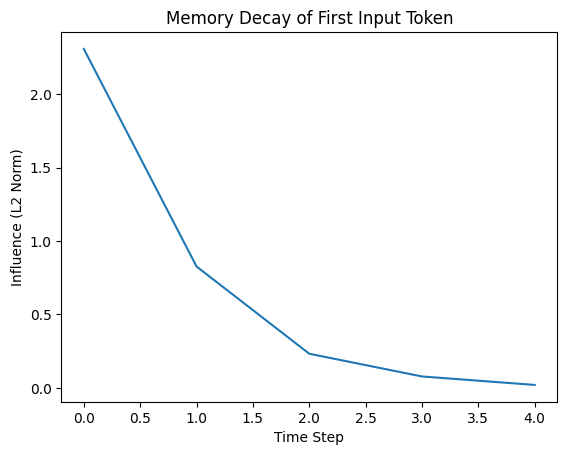

Memory decay (RNN): [2.3084300456074907, 0.8268679967079196, 0.23272350810696577, 0.0779380336690541, 0.020397528017945338]


In [35]:
# 2. Print or plot how its contribution decreases
import matplotlib.pyplot as plt
plt.plot(influence)
plt.title("Memory Decay of First Input Token")
plt.xlabel("Time Step")
plt.ylabel("Influence (L2 Norm)")
plt.show()
print("Memory decay (RNN):", influence)

## LSTM Gate Simulation

In [37]:
# 1. Compute forget, input, and output gates
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Initialize weights
Wf = np.random.randn(hidden_size, hidden_size + len(vocab))
Wi = np.random.randn(hidden_size, hidden_size + len(vocab))
Wo = np.random.randn(hidden_size, hidden_size + len(vocab))
Wc = np.random.randn(hidden_size, hidden_size + len(vocab))

h, c = np.zeros(hidden_size), np.zeros(hidden_size)
lstm_memory = []

In [38]:
# 2. Update cell state and hidden state
for x in encoded_sequence:
    combined = np.concatenate((h, x))
    
    f = sigmoid(Wf @ combined)
    i = sigmoid(Wi @ combined)
    o = sigmoid(Wo @ combined)
    c_tilde = np.tanh(Wc @ combined)
    
    c = f * c + i * c_tilde
    h = o * np.tanh(c)
    
    lstm_memory.append(np.linalg.norm(c))


In [39]:
# 3. Store memory values
print("LSTM Memory:", lstm_memory)

LSTM Memory: [np.float64(0.6627702018399374), np.float64(0.5859455061786685), np.float64(1.1803840098703462), np.float64(1.2636931697382205), np.float64(1.247673337962817)]


## RNN vs LSTM Memory Comparison

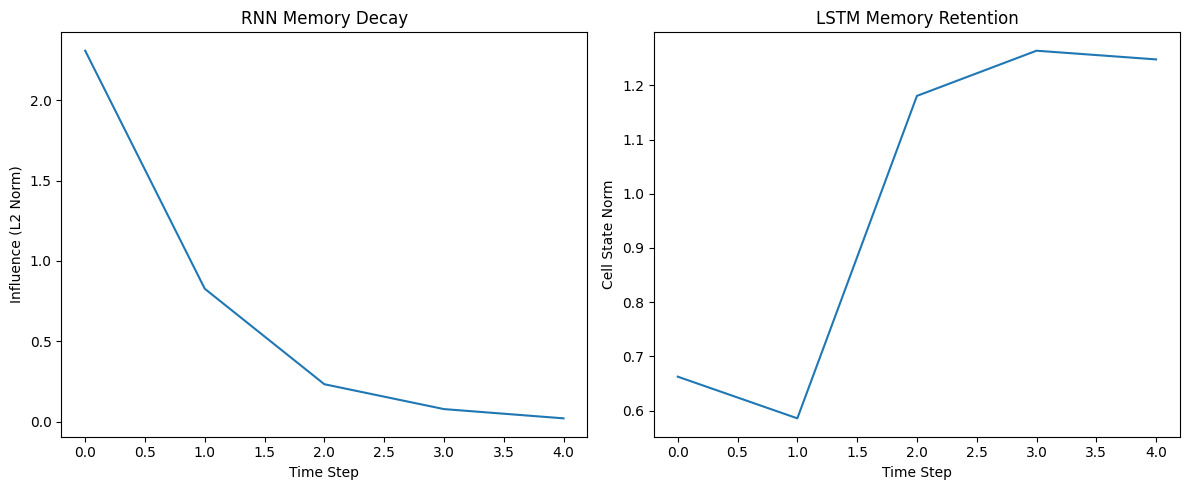


RNN Memory: [2.3084300456074907, 0.8268679967079196, 0.23272350810696577, 0.0779380336690541, 0.020397528017945338]
LSTM Memory: [np.float64(0.6627702018399374), np.float64(0.5859455061786685), np.float64(1.1803840098703462), np.float64(1.2636931697382205), np.float64(1.247673337962817)]


In [40]:
# 1. Compare memory retention curves of RNN and LSTM
# 2. Display results side-by-side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(influence)
plt.title("RNN Memory Decay")
plt.xlabel("Time Step")
plt.ylabel("Influence (L2 Norm)")
plt.subplot(1, 2, 2)
plt.plot(lstm_memory)
plt.title("LSTM Memory Retention")
plt.xlabel("Time Step")
plt.ylabel("Cell State Norm")
plt.tight_layout()
plt.show()
print("\nRNN Memory:", influence)
print("LSTM Memory:", lstm_memory)

## GRU Gate Simulation

In [41]:
# 1. Compute reset and update gates
Wr = np.random.randn(hidden_size, hidden_size + len(vocab))
Wz = np.random.randn(hidden_size, hidden_size + len(vocab))
Wh_gru = np.random.randn(hidden_size, hidden_size + len(vocab))

h = np.zeros(hidden_size)
gru_memory = []

In [42]:
# 2. Update hidden state
for x in encoded_sequence:
    combined = np.concatenate((h, x))
    
    r = sigmoid(Wr @ combined)
    z = sigmoid(Wz @ combined)
    h_tilde = np.tanh(Wh_gru @ np.concatenate((r * h, x)))
    
    h = (1 - z) * h + z * h_tilde
    
    gru_memory.append(np.linalg.norm(h))

In [43]:
# 3. Store GRU memory values
print("GRU Memory:", gru_memory)

GRU Memory: [np.float64(0.8017080625957147), np.float64(0.6131108982814945), np.float64(1.0028406891546076), np.float64(0.9053966242544271), np.float64(1.080222398808778)]


## LSTM vs GRU


LSTM Memory: [np.float64(0.6627702018399374), np.float64(0.5859455061786685), np.float64(1.1803840098703462), np.float64(1.2636931697382205), np.float64(1.247673337962817)]
GRU Memory: [np.float64(0.8017080625957147), np.float64(0.6131108982814945), np.float64(1.0028406891546076), np.float64(0.9053966242544271), np.float64(1.080222398808778)]


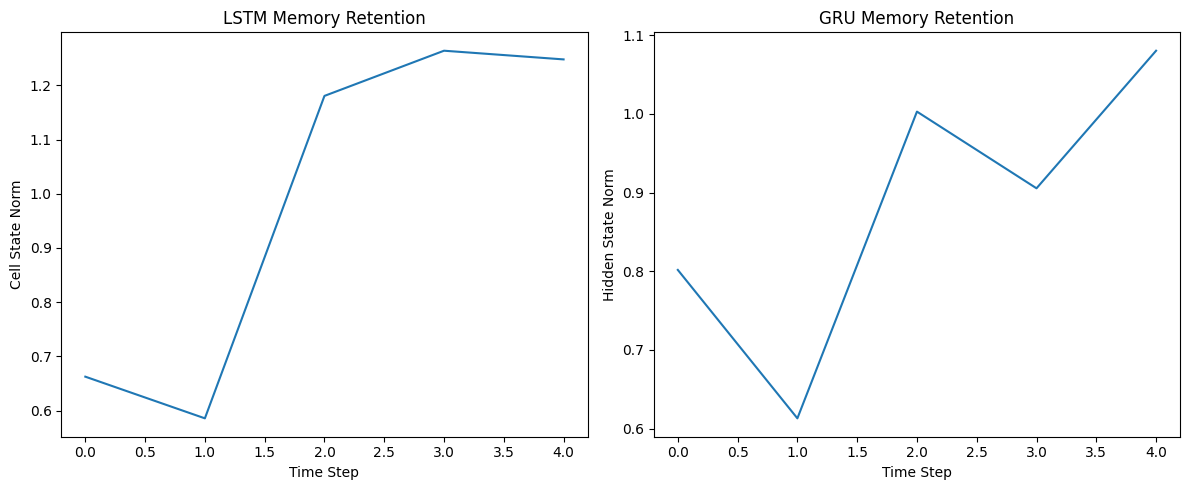


Observations:
- LSTM retains memory longer than GRU, as seen by higher cell state norms.
- GRU shows a more rapid decay in memory retention compared to LSTM.


In [44]:
# 1. Compare memory retention of LSTM and GRU
print("\nLSTM Memory:", lstm_memory)
print("GRU Memory:", gru_memory)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(lstm_memory)
plt.title("LSTM Memory Retention")
plt.xlabel("Time Step")
plt.ylabel("Cell State Norm")
plt.subplot(1, 2, 2)
plt.plot(gru_memory)
plt.title("GRU Memory Retention")
plt.xlabel("Time Step")
plt.ylabel("Hidden State Norm")
plt.tight_layout()
plt.show()

# 2. Print observations
print("\nObservations:")
print("- LSTM retains memory longer than GRU, as seen by higher cell state norms.")
print("- GRU shows a more rapid decay in memory retention compared to LSTM.")

## Unified Visualization

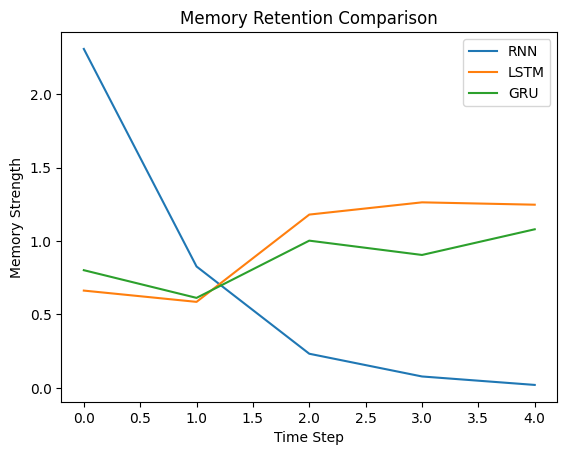

In [45]:
import matplotlib.pyplot as plt

plt.plot(influence, label="RNN")
plt.plot(lstm_memory, label="LSTM")
plt.plot(gru_memory, label="GRU")

plt.legend()
plt.title("Memory Retention Comparison")
plt.xlabel("Time Step")
plt.ylabel("Memory Strength")
plt.show()

## Sequence Prediction

In [46]:
def predict_next(h):
    scores = Wx.T @ h  # simple similarity
    idx = np.argmax(scores)
    return vocab[idx]

rnn_pred = predict_next(hidden_states[-1])
lstm_pred = predict_next(h)  # last h from LSTM
gru_pred = predict_next(h)   # last h from GRU

print("\nNext Predictions:")
print("RNN:", rnn_pred)
print("LSTM:", lstm_pred)
print("GRU:", gru_pred)


Next Predictions:
RNN: there
LSTM: I
GRU: I


## Conceptual Reflection

RNNs fail on long sequences because repeated multiplication of gradients causes them to either shrink (vanish) or explode, making it hard to retain early information. As a result, earlier inputs lose influence quickly over time. LSTMs solve this using a cell state and gating mechanisms (forget, input, output) that control what to keep or discard, allowing gradients to flow more effectively. GRUs simplify this idea with fewer gates while still preserving long-term dependencies reasonably well. Both architectures reduce the vanishing gradient problem significantly. However, they still process sequences sequentially, limiting parallelization. This limitation led to Attention mechanisms and eventually Transformers, which directly connect all tokens and model long-range dependencies more efficiently.